In [1]:
import pandas as pd
import numpy as np



In [2]:
df = pd.read_csv('SuperStoreOrders.csv')

In [3]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [4]:
df.shape

(51290, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [6]:
# missing value
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [7]:
# Duplilcated Row
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

order_id           object
order_date         object
ship_date          object
ship_mode          object
customer_name      object
segment            object
state              object
country            object
market             object
region             object
product_id         object
category           object
sub_category       object
product_name       object
sales              object
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority     object
year                int64
dtype: object

In [9]:
df[['order_date' , 'ship_date' , 'region' , 'category'  , 'sub_category' , 'product_name' , 'sales' , 'profit' , 'quantity']].head()

,order_date,ship_date,region,category,sub_category,product_name,sales,profit,quantity
0,1/1/2011,6/1/2011,Africa,Office Supplies,Storage,"Tenex Lockers, Blue",408,106.140,2
1,1/1/2011,8/1/2011,Oceania,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,36.036,3
2,1/1/2011,5/1/2011,EMEA,Office Supplies,Storage,"Tenex Box, Single Width",66,29.640,4
3,1/1/2011,5/1/2011,North,Office Supplies,Paper,"Enermax Note Cards, Premium",45,-26.055,3
4,1/1/2011,8/1/2011,Oceania,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,37.770,5


In [10]:
df['order_date'].value_counts()

order_date
18-06-2014    135
18-11-2014    127
3/9/2014      126
20-11-2014    118
29-12-2014    116
             ... 
13-01-2013      1
10/11/2013      1
2/1/2011        1
27-05-2012      1
23-03-2014      1
Name: count, Length: 1430, dtype: int64

In [11]:
# date column convert
df['order_date'] = pd.to_datetime(df['order_date'] ,  format='mixed', dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'],  format='mixed',dayfirst=True)

In [12]:
df[['order_date' , 'ship_date']].dtypes

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object

In [13]:
# sales
df['sales'].value_counts()

sales
13       589
11       550
14       527
19       523
17       520
        ... 
1,566      1
1,501      1
2,834      1
3,802      1
1,831      1
Name: count, Length: 2246, dtype: int64

In [14]:
# convert to integer
df['sales'] = df['sales'].str.replace(',' , '' ,regex=False)
df['sales'] = pd.to_numeric(df['sales'])

In [15]:
df['sales'].isnull().sum()

np.int64(0)

In [16]:
df[['sales', 'quantity', 'discount', 'profit', 'shipping_cost']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sales          51290 non-null  int64  
 1   quantity       51290 non-null  int64  
 2   discount       51290 non-null  float64
 3   profit         51290 non-null  float64
 4   shipping_cost  51290 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 2.0 MB


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  int64         
 15  qu

In [20]:
df.describe()

,order_date,ship_date,sales,quantity,discount,profit,shipping_cost,year
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780864,2013-05-15 20:42:42.745174528,246.498440,3.476545,0.142908,28.641740,26.375915,2012.777208
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.000000,14.000000,0.850000,8399.976000,933.570000,2014.000000
std,NaN,NaN,487.567175,2.278766,0.212280,174.424113,57.296804,1.098931


### EDA 

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Sales distribution
df['sales'].describe()

count    51290.000000
mean       246.498440
std        487.567175
min          0.000000
25%         31.000000
50%         85.000000
75%        251.000000
max      22638.000000
Name: sales, dtype: float64

<Axes: xlabel='sales', ylabel='Count'>

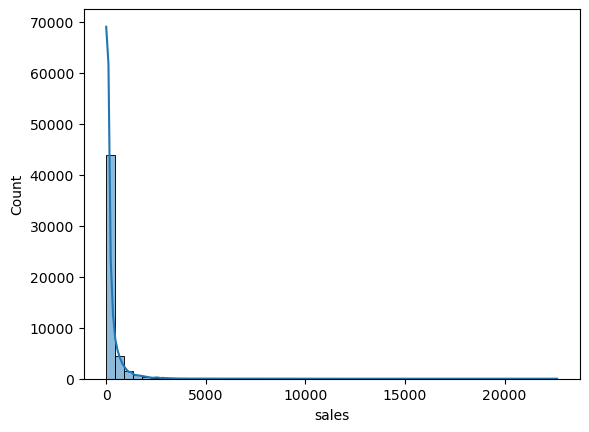

In [23]:
sns.histplot(df['sales'] , bins =50 , kde = True) 

<Axes: xlabel='sales'>

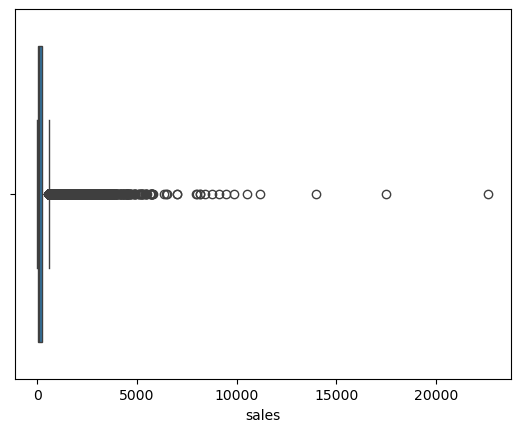

In [24]:
# outliers
sns.boxplot(x=df['sales'])

In [25]:
# IQR method using Sales
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)

IQR = Q3 - Q1
lower =  Q1 - 1.5 * IQR
upper =  Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)


Q1: 31.0
Q3: 251.0
IQR: 220.0
Lower Bound: -299.0
Upper Bound: 581.0


In [26]:
outliers = df[(df['sales'] < lower) | (df['sales'] > upper)]

print("Outliers:", len(outliers))

Outliers: 5655


In [27]:
outliers['sales'].describe()

count     5655.000000
mean      1253.864721
std        935.981609
min        582.000000
25%        726.000000
50%        956.000000
75%       1444.500000
max      22638.000000
Name: sales, dtype: float64

In [28]:
outliers[['order_id', 'product_name', 'sales', 'profit']].sort_values(
    'sales', ascending=False
).head(20)

,order_id,product_name,sales,profit
1103,CA-2011-145317,Cisco TelePresence System EX90 Videoconferenci...,22638,-1811.0784
29530,CA-2013-118689,Canon imageCLASS 2200 Advanced Copier,17500,8399.9760
36239,CA-2014-140151,Canon imageCLASS 2200 Advanced Copier,14000,6719.9808
46525,CA-2014-127180,Canon imageCLASS 2200 Advanced Copier,11200,3919.9888
48097,CA-2014-166709,Canon imageCLASS 2200 Advanced Copier,10500,5039.9856
33011,CA-2013-117121,GBC Ibimaster 500 Manual ProClick Binding System,9893,4946.3700
5522,CA-2011-116904,Ibico EPK-21 Electric Binding System,9450,4630.4755
22483,US-2013-107440,"3D Systems Cube Printer, 2nd Generation, Magenta",9100,2365.9818
20693,CA-2013-158841,HP Designjet T520 Inkjet Large Format Printer ...,8750,2799.9840
23575,CA-2013-143714,Canon imageCLASS 2200 Advanced Copier,8400,1119.9968


In [29]:
# IQR method using profit
Q1 = df['profit'].quantile(0.25)
Q3 = df['profit'].quantile(0.75)

IQR = Q3 - Q1
lower =  Q1 - 1.5 * IQR
upper =  Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)


Q1: 0.0
Q3: 36.81
IQR: 36.81
Lower Bound: -55.215
Upper Bound: 92.025


In [30]:
profit_outliers = df[
    (df['profit'] < lower) |
    (df['profit'] > upper)
]

print("Profit outliers:", len(profit_outliers))

Profit outliers: 9755


In [31]:
profit_outliers[['order_id', 'product_name', 'sales', 'profit']].sort_values(
    'profit', ascending=False
).head(20)

,order_id,product_name,sales,profit
29530,CA-2013-118689,Canon imageCLASS 2200 Advanced Copier,17500,8399.9760
36239,CA-2014-140151,Canon imageCLASS 2200 Advanced Copier,14000,6719.9808
48097,CA-2014-166709,Canon imageCLASS 2200 Advanced Copier,10500,5039.9856
33011,CA-2013-117121,GBC Ibimaster 500 Manual ProClick Binding System,9893,4946.3700
5522,CA-2011-116904,Ibico EPK-21 Electric Binding System,9450,4630.4755
43831,ES-2014-1651774,"Hoover Stove, Red",7959,3979.0800
46525,CA-2014-127180,Canon imageCLASS 2200 Advanced Copier,11200,3919.9888
10265,CA-2012-145352,Fellowes PB500 Electric Punch Plastic Comb Bin...,6355,3177.4750
548,ID-2011-64599,"Samsung Smart Phone, VoIP",6999,2939.3100
24420,IN-2013-50809,"Apple Smart Phone, with Caller ID",5752,2817.9900


In [32]:
profit_outliers[['order_id', 'product_name', 'sales', 'profit']].sort_values(
    'profit'
).head(20)

,order_id,product_name,sales,profit
31884,CA-2013-108196,Cubify CubeX 3D Printer Double Head Print,4500,-6599.9780
29212,TU-2013-9400,"Motorola Smart Phone, Cordless",3085,-4088.3760
47195,US-2014-168116,Cubify CubeX 3D Printer Triple Head Print,8000,-3839.9904
3775,CA-2011-169019,GBC DocuBind P400 Electric Binding System,2178,-3701.8928
37130,CA-2014-134845,Lexmark MX611dhe Monochrome Laser Printer,2550,-3399.9800
24286,IT-2013-3695467,"Hoover Stove, White",3400,-3059.8200
28510,ID-2013-12295,"Apple Smart Phone, Full Size",3499,-3009.4350
49628,US-2014-122714,Ibico EPK-21 Electric Binding System,1890,-2929.4845
34513,LH-2014-5390,"Barricks Conference Table, Rectangular",2171,-2750.2800
19251,CA-2012-147830,Cubify CubeX 3D Printer Double Head Print,1800,-2639.9912


In [33]:
print("Total Sales:", df['sales'].sum())
print("Total Profit:", df['profit'].sum())
print("Total Quantity:", df['quantity'].sum())

Total Sales: 12642905
Total Profit: 1469034.82128
Total Quantity: 178312


In [34]:
profit_margin  = (df['profit'].sum() / df['sales'].sum()) *100
print("Profit Margin : " , profit_margin)

Profit Margin :  11.619440478908922


In [35]:
df['region'].value_counts()

region
Central           11117
South              6645
EMEA               5029
North              4785
Africa             4587
Oceania            3487
West               3203
Southeast Asia     3129
East               2848
North Asia         2338
Central Asia       2048
Caribbean          1690
Canada              384
Name: count, dtype: int64

In [36]:
region_analysis = df.groupby('region').agg(
    Sales=('sales', 'sum'),
    Profit=('profit', 'sum'),
    Quantity=('quantity', 'sum')
).sort_values('Sales' , ascending=False)

In [37]:
region_analysis

,Sales,Profit,Quantity
region,,,
Central,2822399,311403.98164,41762
South,1600960,140355.76618,25206
North,1248192,194597.95252,18021
Oceania,1100207,121666.64200,12838
Southeast Asia,884438,17852.32900,11822
North Asia,848349,165578.42100,8851
EMEA,806184,43897.97100,11517
Africa,783776,88871.63100,10564
Central Asia,752839,132480.18700,7715


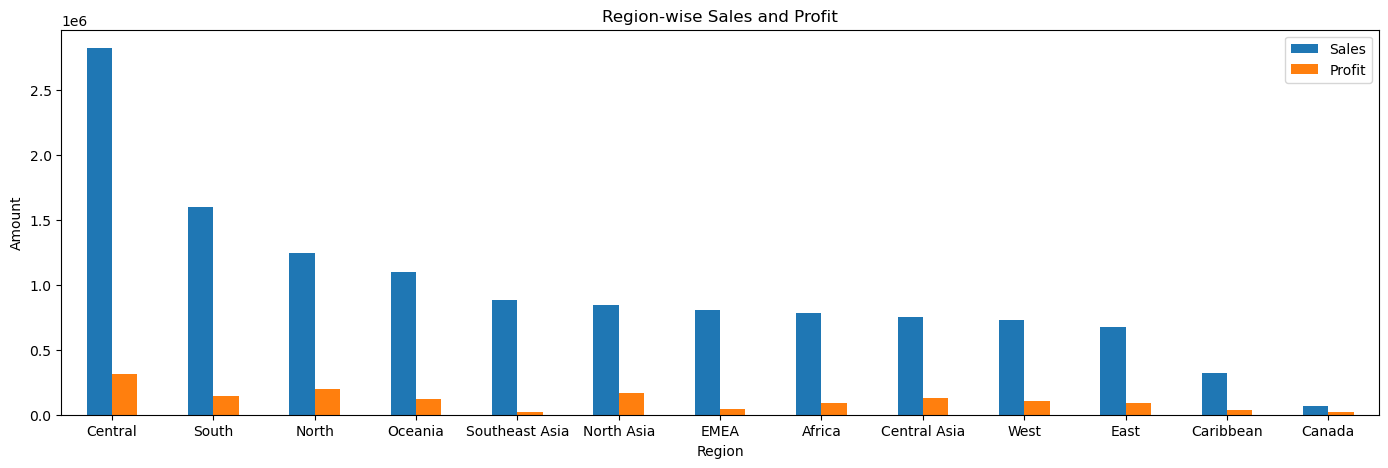

In [38]:
region_analysis[['Sales', 'Profit']].plot(
    kind='bar',
    figsize=(17,5)
)

plt.title('Region-wise Sales and Profit')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

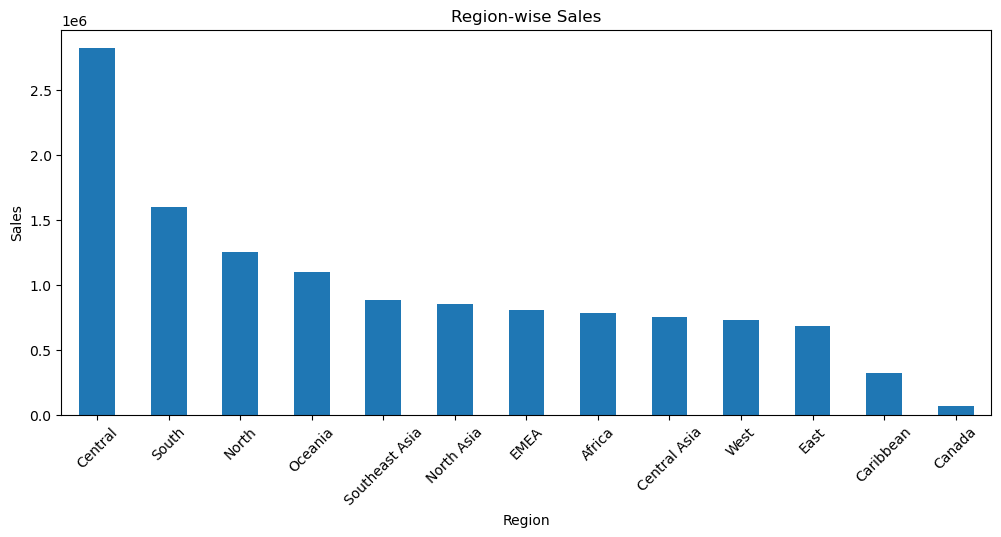

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))

region_analysis['Sales'].plot(kind='bar', ax=ax)

ax.set_title('Region-wise Sales')
ax.set_xlabel('Region')
ax.set_ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

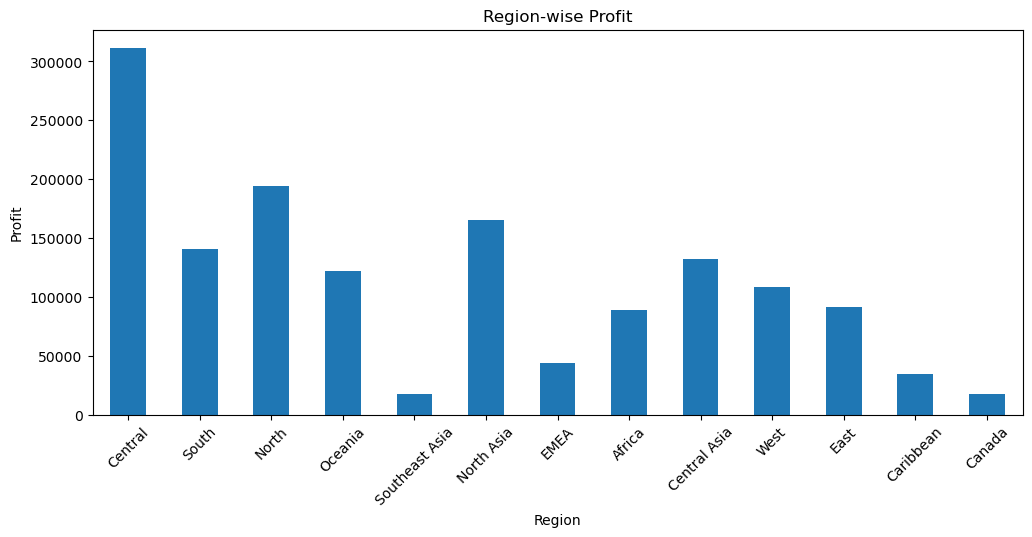

In [40]:
fig, ax = plt.subplots(figsize=(12, 5))

region_analysis['Profit'].plot(kind='bar', ax=ax)

ax.set_title('Region-wise Profit')
ax.set_xlabel('Region')
ax.set_ylabel('Profit')
plt.xticks(rotation=45)
plt.show()

In [41]:
df['category'].value_counts()

category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64

In [42]:
category_analysis = df.groupby('category').agg(
    Sales=('sales', 'sum'),
    Profit=('profit', 'sum'),
    Quantity=('quantity', 'sum')
).sort_values('Sales' , ascending=False)

In [43]:
category_analysis

,Sales,Profit,Quantity
category,,,
Technology,4744691,663778.73318,35176
Furniture,4110884,286782.25380,34954
Office Supplies,3787330,518473.83430,108182


In [44]:
subcat_analysis = df.groupby('sub_category').agg(
    Sales=('sales', 'sum'),
    Profit=('profit', 'sum'),
    Quantity=('quantity', 'sum')
).sort_values('Sales' , ascending=False)

In [45]:
subcat_analysis

,Sales,Profit,Quantity
sub_category,,,
Phones,1706874,216717.00580,11870
Copiers,1509439,258567.54818,7454
Chairs,1501682,141973.79750,12336
Bookcases,1466559,161924.41950,8310
Storage,1127124,108461.48980,16917
Appliances,1011081,141680.58940,6078
Machines,779071,58867.87300,4906
Tables,757034,-64083.38870,3083
Accessories,749307,129626.30620,10946


In [46]:
# monthly sales trend 
montly_sales = df.groupby(
    df['order_date'].dt.to_period('M')
).agg(
    Sales = ('sales' , 'sum'),
    Profit = ('profit' , 'sum')
).reset_index()

montly_sales['order_date'] = montly_sales['order_date'].astype(str)

montly_sales.head(5)

,order_date,Sales,Profit
0,2011-01,98902,8321.80096
1,2011-02,91152,12417.90698
2,2011-03,145726,15303.56826
3,2011-04,116927,12902.32438
4,2011-05,146762,12183.82870


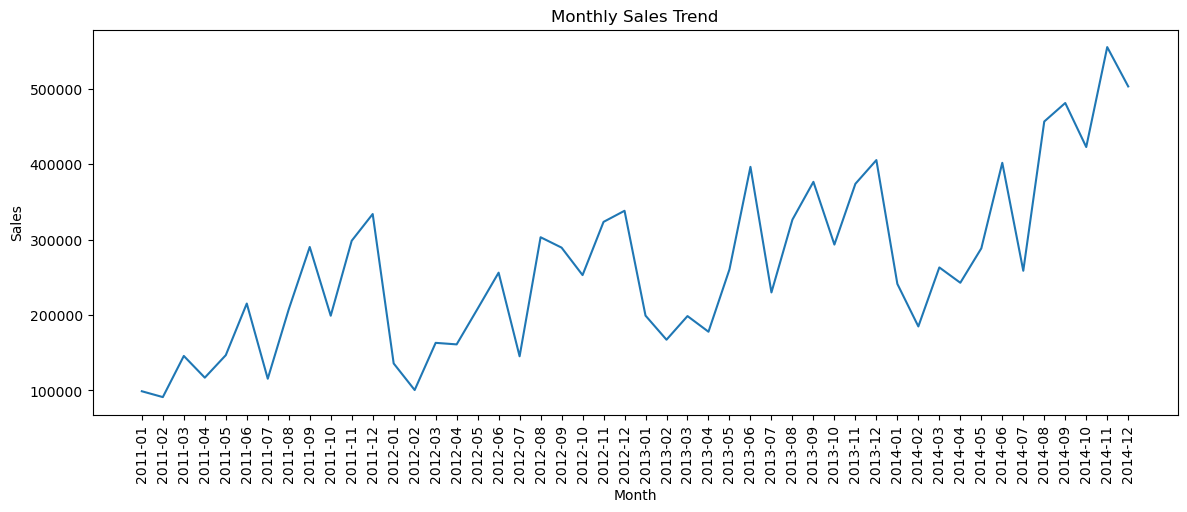

In [47]:
# Sales TRend
plt.figure(figsize=(14,5))
sns.lineplot(
    data = montly_sales,
    x='order_date',
    y='Sales'
)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.show()


In [48]:
year_analysis = df.groupby('year').agg(
    Sales=('sales', 'sum'),
    Profit=('profit', 'sum'),
    Quantity=('quantity', 'sum')
)

year_analysis

,Sales,Profit,Quantity
year,,,
2011,2259511,248940.81154,31443
2012,2677493,307415.27910,38111
2013,3405860,408512.76018,48136
2014,4300041,504165.97046,60622


In [49]:
year_analysis['Sales_Growth_%'] = (
    year_analysis['Sales'].pct_change() * 100
)

year_analysis

,Sales,Profit,Quantity,Sales_Growth_%
year,,,,
2011,2259511,248940.81154,31443,NaN
2012,2677493,307415.27910,38111,18.498781
2013,3405860,408512.76018,48136,27.203320
2014,4300041,504165.97046,60622,26.254191


In [50]:
top_products = df.groupby('product_name').agg(
    Sales=('sales', 'sum'),
    Profit=('profit', 'sum'),
    Quantity=('quantity', 'sum')
).sort_values('Sales', ascending=False).head(10)

top_products

,Sales,Profit,Quantity
product_name,,,
"Apple Smart Phone, Full Size",86936,5921.5786,171
"Cisco Smart Phone, Full Size",76441,17238.5206,139
"Motorola Smart Phone, Full Size",73159,17027.1130,134
"Nokia Smart Phone, Full Size",71904,9938.1955,147
Canon imageCLASS 2200 Advanced Copier,61600,25199.9280,20
"Hon Executive Leather Armchair, Adjustable",58200,5997.2541,169
"Office Star Executive Leather Armchair, Adjustable",50667,4710.9840,141
"Harbour Creations Executive Leather Armchair, Adjustable",50120,10427.3260,142
"Samsung Smart Phone, Cordless",48654,-198.0900,108


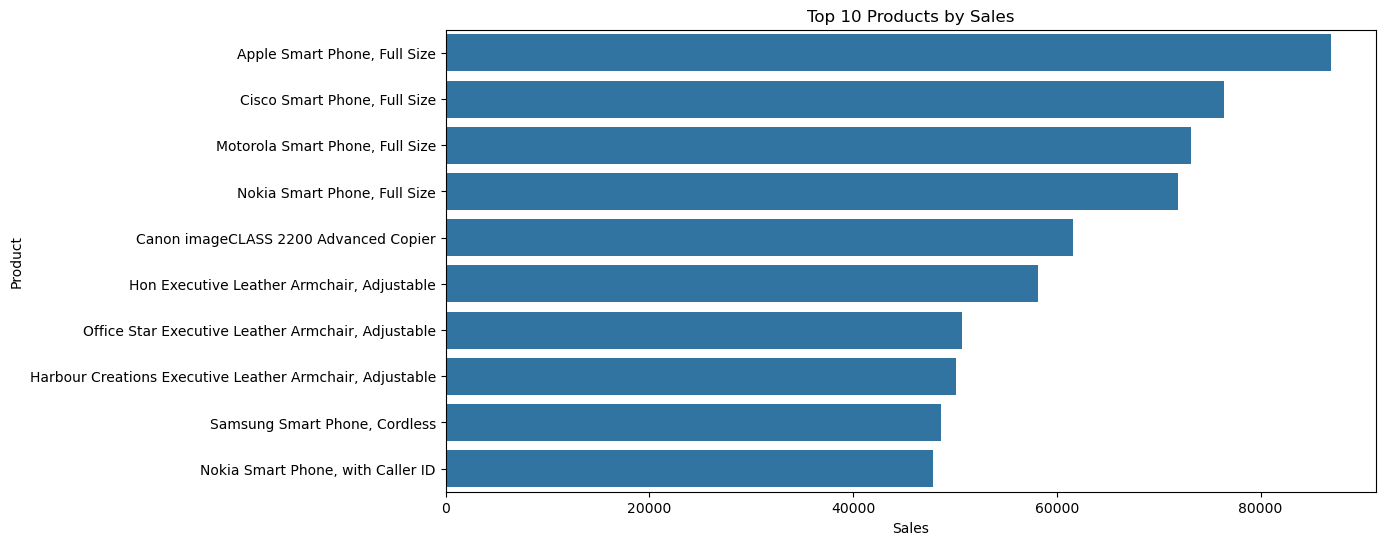

In [51]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_products['Sales'],
    y=top_products.index
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.show()

In [52]:
# customer segment 
segment_analysis = df.groupby('segment').agg(
    Sales=('sales', 'sum'),
    Profit=('profit', 'sum'),
    Quantity=('quantity', 'sum')
).sort_values('Sales', ascending=False)

segment_analysis

,Sales,Profit,Quantity
segment,,,
Consumer,6508141,749239.78206,92157
Corporate,3824808,442785.85866,53565
Home Office,2309956,277009.18056,32590


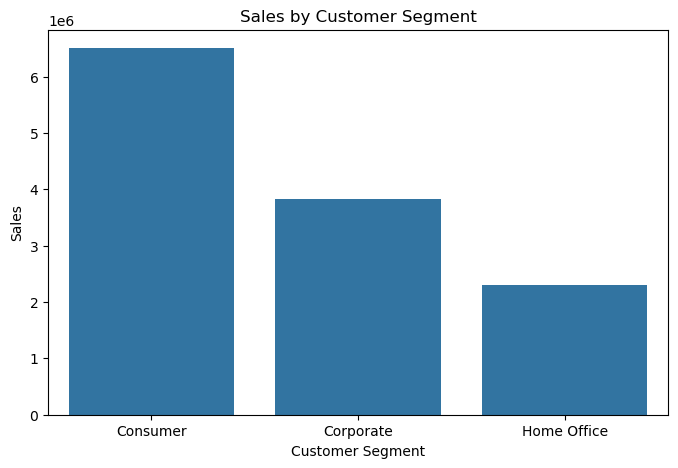

In [53]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_analysis.reset_index(),
    x='segment',
    y='Sales'
)

plt.title('Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Sales')

plt.show()

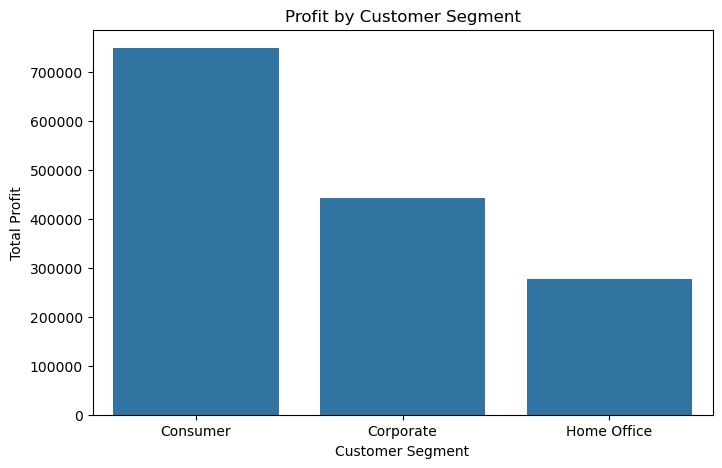

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_analysis.reset_index(),
    x='segment',
    y='Profit'
)

plt.title('Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Profit')

plt.show()

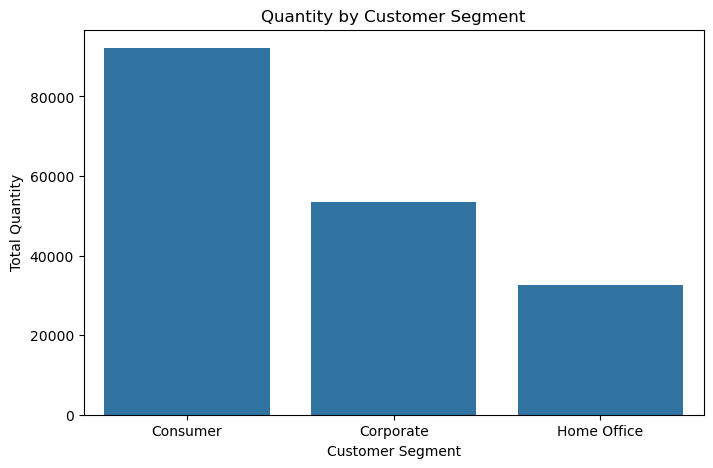

In [55]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_analysis.reset_index(),
    x='segment',
    y='Quantity'
)

plt.title('Quantity by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Quantity')

plt.show()

In [56]:
# Profitability Analaysis
top_profit_products = df.groupby('product_name').agg(
    Sales=('sales', 'sum'),
    Profit=('profit', 'sum'),
    Quantity=('quantity', 'sum')
).sort_values('Profit', ascending=False).head(10)

top_profit_products

,Sales,Profit,Quantity
product_name,,,
Canon imageCLASS 2200 Advanced Copier,61600,25199.9280,20
"Cisco Smart Phone, Full Size",76441,17238.5206,139
"Motorola Smart Phone, Full Size",73159,17027.1130,134
"Hoover Stove, Red",31664,11807.9690,62
"Sauder Classic Bookcase, Traditional",39110,10672.0730,113
"Harbour Creations Executive Leather Armchair, Adjustable",50120,10427.3260,142
"Nokia Smart Phone, Full Size",71904,9938.1955,147
"Cisco Smart Phone, with Caller ID",43124,9786.6408,85
"Nokia Smart Phone, with Caller ID",47880,9465.3257,96


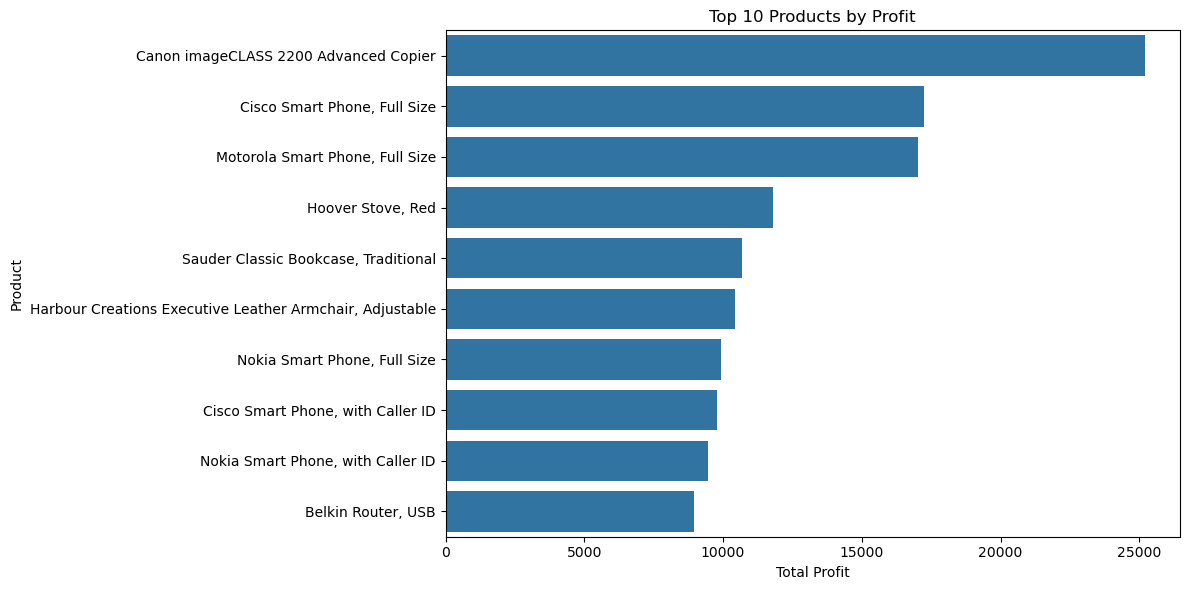

In [57]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_profit_products.reset_index(),
    x='Profit',
    y='product_name'
)

plt.title('Top 10 Products by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [58]:
bottom_profit_products = df.groupby('product_name').agg(
    Sales=('sales', 'sum'),
    Profit=('profit', 'sum'),
    Quantity=('quantity', 'sum')
).sort_values('Profit', ascending=True).head(10)

bottom_profit_products

,Sales,Profit,Quantity
product_name,,,
Cubify CubeX 3D Printer Double Head Print,11100,-8879.9704,9
Lexmark MX611dhe Monochrome Laser Printer,16830,-4589.9730,18
"Motorola Smart Phone, Cordless",38935,-4447.0380,74
Cubify CubeX 3D Printer Triple Head Print,8000,-3839.9904,4
"Bevis Round Table, Adjustable Height",5655,-3649.8940,22
"Bevis Computer Table, Fully Assembled",11176,-3509.5638,43
"Rogers Lockers, Blue",28215,-2893.4908,167
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9918,-2876.1156,27
"Bevis Wood Table, with Bottom Storage",11134,-2782.5880,34


In [59]:
# Discount Anlaysis and Profit Analaysis
discount_analysis = df.groupby('discount').agg(
    Sales = ('sales' , 'sum'),
    Profit = ('profit' , 'sum'),
    Quantity = ('quantity' , 'sum')

).reset_index()

discount_analysis

,discount,Sales,Profit,Quantity
0,0.000,6992734,1.770695e+06,98768
1,0.002,261395,5.797658e+04,1657
2,0.070,121620,2.114850e+04,533
3,0.100,1579618,2.606417e+05,15417
4,0.150,306037,2.737590e+04,2021
5,0.170,247404,2.816307e+04,2720
6,0.200,1203855,1.177159e+05,18653
7,0.202,16213,-5.952727e+02,135
8,0.250,88063,8.005875e+02,826
9,0.270,89351,-1.675079e+03,1453


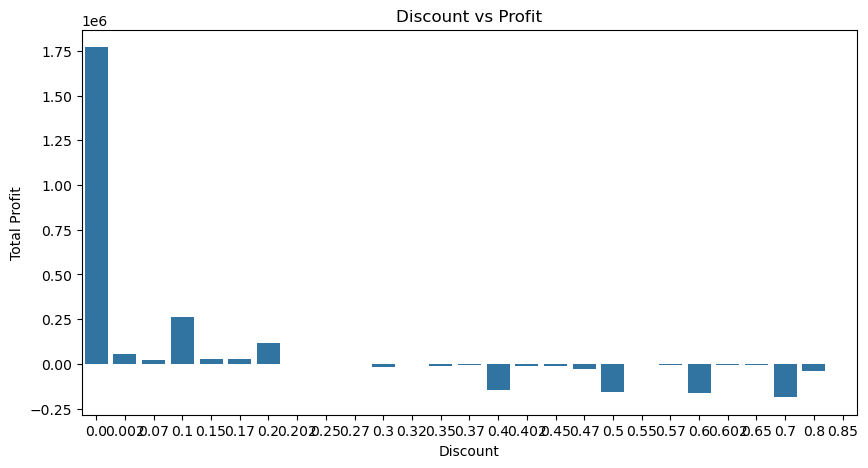

In [60]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=discount_analysis,
    x='discount',
    y='Profit'
)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Total Profit')

plt.show()

In [61]:
df[['discount', 'profit']].corr()

,discount,profit
discount,1.000000,-0.316375
profit,-0.316375,1.000000


In [62]:
# Country Wise Amalysis
country_analysis = df.groupby('country').agg(
    Sales=('sales', 'sum'),
    Profit=('profit', 'sum'),
    Quantity=('quantity', 'sum')
).sort_values('Sales', ascending=False)

country_analysis.head(10)

,Sales,Profit,Quantity
country,,,
United States,2297354,286397.02170,37873
Australia,925257,105484.96300,10673
France,858930,109029.00300,10804
China,700591,150683.08500,7081
Germany,628857,107322.82050,7745
Mexico,622620,102818.09752,10011
India,589664,129071.83500,5758
United Kingdom,528570,111900.15000,6161
Indonesia,404887,15608.67790,5237


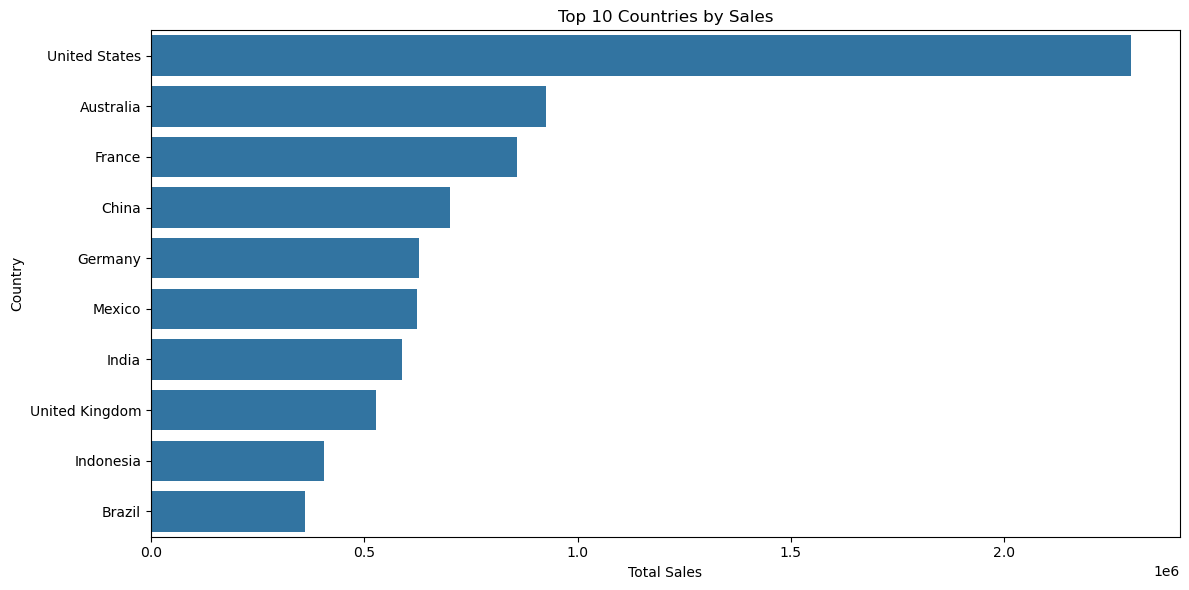

In [63]:
top_countries = country_analysis.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_countries.reset_index(),
    x='Sales',
    y='country'
)

plt.title('Top 10 Countries by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

In [64]:
bottom_countries_profit = country_analysis.sort_values(
    'Profit',
    ascending=True
).head(10)

bottom_countries_profit

,Sales,Profit,Quantity
country,,,
Turkey,108524,-98447.23200,3024
Nigeria,54347,-80750.71800,2056
Netherlands,77520,-41070.07500,1682
Honduras,90137,-29482.37140,2556
Pakistan,58873,-22446.64800,948
Argentina,57510,-18693.79672,1504
Panama,51556,-17723.45248,1426
Sweden,30490,-17519.36700,753
Philippines,183433,-16128.22500,2606


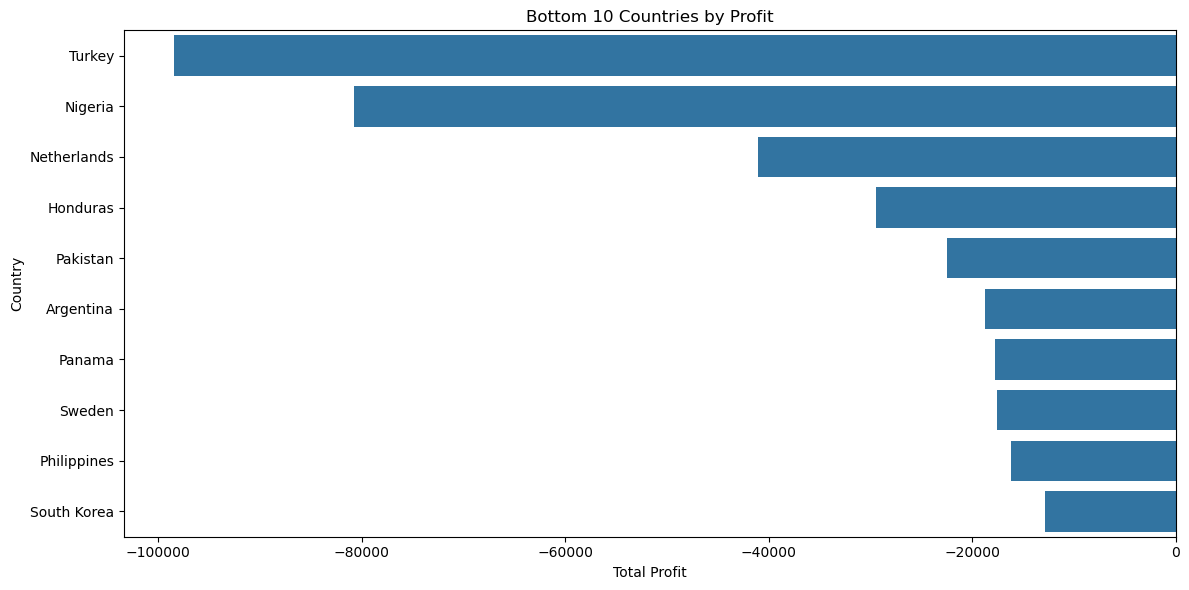

In [65]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=bottom_countries_profit.reset_index(),
    x='Profit',
    y='country'
)

plt.title('Bottom 10 Countries by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

In [66]:
# Montly profit trend 
monthly_profit = df.groupby(
    df['order_date'].dt.to_period('M')
).agg(
    Profit=('profit', 'sum')
).reset_index()

monthly_profit['order_date'] = monthly_profit['order_date'].astype(str)

monthly_profit.head()

,order_date,Profit
0,2011-01,8321.80096
1,2011-02,12417.90698
2,2011-03,15303.56826
3,2011-04,12902.32438
4,2011-05,12183.82870


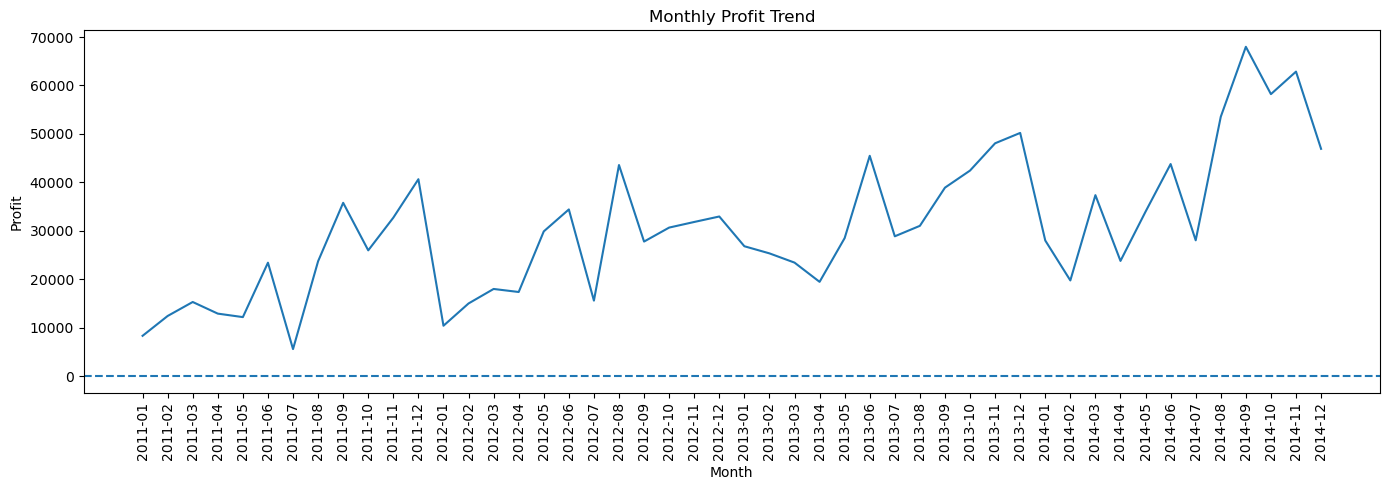

In [67]:
plt.figure(figsize=(14,5))

sns.lineplot(
    data=monthly_profit,
    x='order_date',
    y='Profit'
)

plt.axhline(0, linestyle='--')

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [68]:
#  Shipping and Delivery Analysis
df['delivery_days'] = (
    df['ship_date'] - df['order_date']
).dt.days

In [69]:
df['delivery_days'].describe()

count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: delivery_days, dtype: float64

In [70]:
shipping_analysis = df.groupby('ship_mode').agg(
    Orders=('order_id', 'nunique'),
    Avg_Delivery_Days=('delivery_days', 'mean'),
    Sales=('sales', 'sum'),
    Profit=('profit', 'sum')
).sort_values('Orders', ascending=False)

shipping_analysis

,Orders,Avg_Delivery_Days,Sales,Profit
ship_mode,,,,
Standard Class,15154,4.998018,7578889,890596.02120
Second Class,5119,3.230187,2565747,294161.05708
First Class,3821,2.181746,1831067,208104.67520
Same Day,1347,0.037394,667202,76173.06780


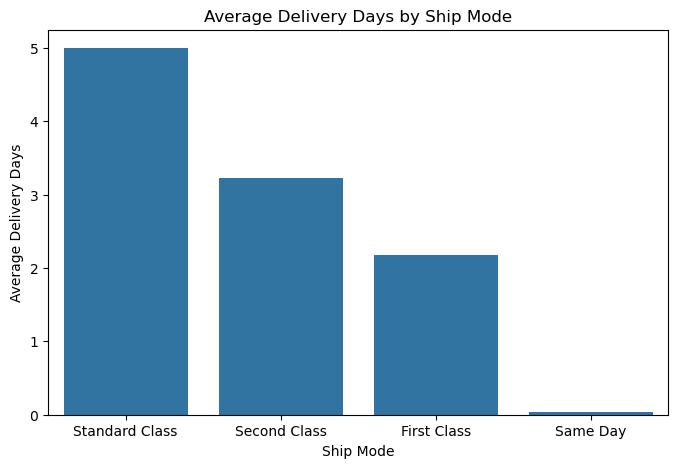

In [71]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=shipping_analysis.reset_index(),
    x='ship_mode',
    y='Avg_Delivery_Days'
)

plt.title('Average Delivery Days by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Average Delivery Days')

plt.show()

In [72]:
df.to_csv("Superstore_Cleaned.csv", index=False)

In [73]:
import os

os.path.exists("Superstore_Cleaned.csv")

True

In [74]:
os.getcwd()

'f:\\hr project'

In [75]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,delivery_days
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011,5
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011,7
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011,4
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011,4
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011,7
